In [4]:
import numpy as np

def erroquadratico(alvo, saida):
  return np.mean((alvo - saida)**2)

def gradiente(alvo, saida):
  return 2*(alvo - saida)

def preditor(x, w, b):
  return w*x + b

def backprop(x, y_real, w, b, taxa):
  y_pred = preditor(x, w, b)
  erro = erroquadratico(y_real, y_pred)

  grad_w = -gradiente(y_real, y_pred) * x
  grad_b = -gradiente(y_real, y_pred)

  w -= taxa * np.mean(grad_w)
  b -= taxa * np.mean(grad_b)

  return w, b, erro


def sigmoid(x):
  return 1/(1+np.exp(-(x**2)))

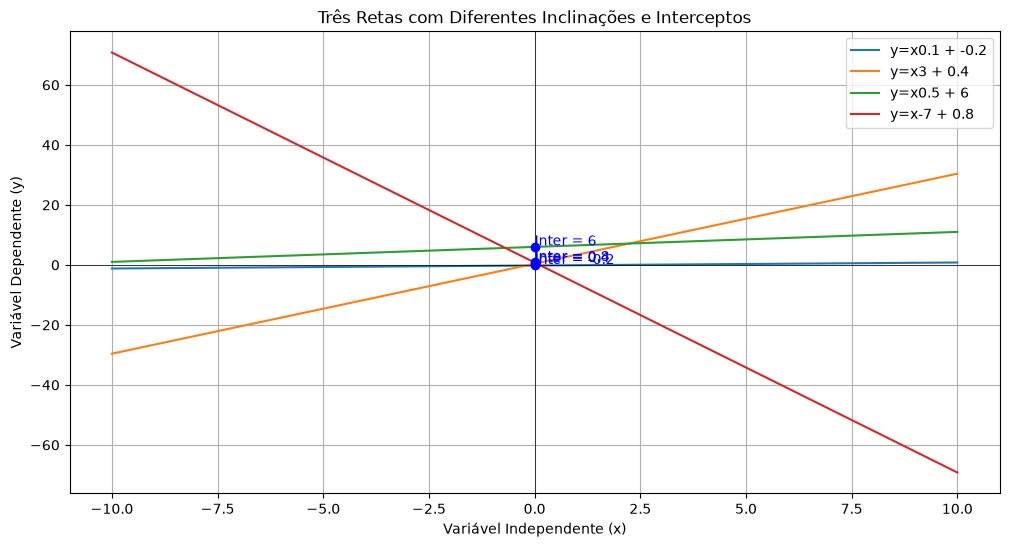

In [5]:
import numpy as np
import matplotlib.pyplot as plt

params = [
    {"a": 0.1, "b": -0.2},
    {"a": 3, "b": 0.4},
    {"a": 0.5, "b": 6},
    {"a": -7, "b": 0.8},
]

x = np.linspace(-10, 10, 200)

plt.figure(figsize=(12, 6))

for param in params:
    a = param["a"]
    b = param["b"]
    y = a * x + b
    plt.plot(x, y, label=f"y=x{a} + {b}")

    plt.scatter(0, b, color='blue', zorder=5)
    plt.text(0, b + 0.5, f"Inter = {b}", color="blue")

plt.title('Três Retas com Diferentes Inclinações e Interceptos')
plt.xlabel('Variável Independente (x)')
plt.ylabel('Variável Dependente (y)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()

plt.show()

In [6]:
##passos dinamicos

def pd(base, limite):
  exponte = 0

  while True:
    for mult in base:
      v = mult * (10 ** exponte)
      if v > limite:
        return
      yield v

    exponte += 1


In [8]:
import matplotlib.pyplot as plt
import numpy as np


# pessos e bias randoms
def pbr(entradas: np.array, ocults: list[int], n_saidas: int):
  n_entradas = len(entradas)

  pesos = []
  bias = []

  pesos.append(np.random.randn(n_entradas, ocults[0]))
  bias.append(np.random.randn(ocults[0]))

  for i in range(1, len(ocults)):
    pesos.append(np.random.randn(ocults[i-1], ocults[i]))
    bias.append(np.random.randn(ocults[i]))

  pesos.append(np.random.randn(ocults[-1], n_saidas))
  bias.append(np.random.randn(n_saidas))

  return pesos, bias



passo 1: 
	 perda 0.46 
	 erro maximo 0.97 
	 gradiente 0.06
passo 5: 
	 perda 0.52 
	 erro maximo 1.01 
	 gradiente 0.06
passo 10: 
	 perda 0.61 
	 erro maximo 1.08 
	 gradiente 0.07
passo 50: 
	 perda 2.65 
	 erro maximo 1.97 
	 gradiente 0.15
passo 100: 
	 perda 106.85 
	 erro maximo 10.61 
	 gradiente 0.98
passo 500: 
	 perda 4524455591386400.00 
	 erro maximo 67264073.93 
	 gradiente 6406102.24

w = 1.1866   b = 6.0680   v = -11051540477044312.0000   c = -11051540477044312.0000


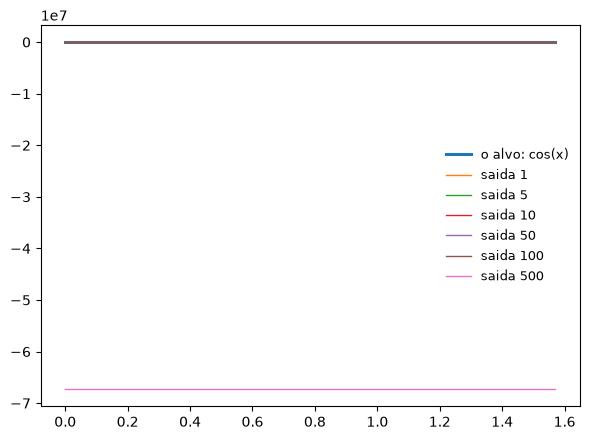

In [9]:
import matplotlib.pyplot as plt
import numpy as np

w, b = -.2, np.random.randn()*1e-2
v, c = .1 , np.random.randn()*1e-2

taxa = 0.01
passos = 1000


x = np.linspace(0, np.pi/2, 21)
n = x.size
x_all = np.linspace(-np.pi, np.pi, 21)
alvo = np.cos(x)
alvo_all = np.sin(x_all)

curvas = {}

for passo in range(passos):

  z = w*x + b
  h = sigmoid(z)
  y= v*h + c

  erro = alvo - y
  L = erro**2

  dL = 2*erro/n
  dc= float(dL @ h)
  dv = float(dL.sum())
  dz = (v*dL*(1 - h**2))
  dw = float(dz @ x)
  db = float(dz.sum())


  if passo in pd([1, 5], passos):
    print(f"passo {passo}: \n\t perda {L.mean():.2f} \n\t erro maximo {np.abs(erro).max():.2f} \n\t gradiente {dL.mean():.2f}")
    curvas[passo] = y.copy()

  if passos == passo: break

  w -= taxa*dw
  b -= taxa*db
  v -= taxa*dv
  c -= taxa*dc

print(f"\nw = {w:.4f}   b = {b:.4f}   v = {v:.4f}   c = {c:.4f}")

size = 6
aspect = (9/12)
fig, ax = plt.subplots(figsize=(size, size*aspect))
ax.plot(x, alvo, lw=2.2, label="o alvo: cos(x)")
for passo, curva in curvas.items():
    ax.plot(x, curva, lw=1, label=f"saida {passo}")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

#ax.plot(x, y, ".", lw=2.2, label="o que o neuronio devolve")
#ax.plot(x, erro, ".", lw=2.2, label="erro")
#ax.plot(x, L, ".", lw=2.2, label="distancia quadrada")
#ax.plot(x, dL, "-", lw=2.2, label="gradiente")
ax.legend(by_label.values(), by_label.keys(), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


In [11]:
import numpy, pandas, matplotlib, sklearn, cv2
print("numpy       ", numpy.__version__)
print("pandas      ", pandas.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)
print("opencv      ", cv2.__version__)

numpy        2.5.3
pandas       3.0.6
matplotlib   3.11.2
scikit-learn 1.9.1
opencv       5.0.0


In [12]:
import numpy as np

sigmoid = lambda t: 1/(1+np.exp(-t))

#create_and_calc_random_neuro
def ccrn(entreada,n_entradas, n_saidas):
  pesos = np.random.randn(n_entradas, n_saidas)
  bias = np.random.randn(n_saidas)
  return sigmoid(entreada @ pesos + bias)


def crnn(entradas):
  n_layers = len(entradas)
  neuro = []
  neuro.append(ccrn(canetas, 4, n_layers))
  for i in range(n_layers): neuro.append(ccrn(neuro[i],n_layers, n_layers))
  return ccrn(neuro[n_layers],n_layers,1)


In [3]:
import numpy as np

eh_caneta = [
    1, # altura
    0.001, # largura
    0.001, # comprimento
    1, # risca? 0 - não, 1 - sim
]


canetas = np.array(eh_caneta)



n_layers = 100;

saida = crnn(canetas)


print(saida)
if saida > 0.5:
    print("é caneta")
else:
    print("não é caneta")

[0.56181476]
é caneta
